In [1]:
!wget -q "https://www.timeseriesclassification.com/aeon-toolkit/FordA.zip"
!unzip -q FordA.zip

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import time
import random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [10]:
train = pd.read_csv("FordA_TRAIN.txt", header=None, sep=r'\s+')
test  = pd.read_csv("FordA_TEST.txt",  header=None, sep=r'\s+')

X_train = train.iloc[:, 1:].values.astype(np.float32)
y_train = train.iloc[:, 0].values
X_test  = test.iloc[:, 1:].values.astype(np.float32)
y_test  = test.iloc[:, 0].values

le = LabelEncoder()
y_train = le.fit_transform(y_train).astype(np.int64)
y_test  = le.transform(y_test).astype(np.int64)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Sequence length: {X_train.shape[1]}")
print(f"Classes: {len(np.unique(y_train))}")
print(f"Class distribution (train): {np.bincount(y_train)}")
print(f"Class distribution (test): {np.bincount(y_test)}")

Train: (3601, 500), Test: (1320, 500)
Sequence length: 500
Classes: 2
Class distribution (train): [1846 1755]
Class distribution (test): [681 639]


In [11]:
mean = X_train.mean(axis=1, keepdims=True)
std  = X_train.std(axis=1, keepdims=True) + 1e-8
X_train_norm = (X_train - mean) / std

mean = X_test.mean(axis=1, keepdims=True)
std  = X_test.std(axis=1, keepdims=True) + 1e-8
X_test_norm = (X_test - mean) / std

X_train_t = torch.tensor(X_train_norm).unsqueeze(1)  # (batch, 1, 500)
X_test_t  = torch.tensor(X_test_norm).unsqueeze(1)
y_train_t = torch.tensor(y_train)
y_test_t  = torch.tensor(y_test)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t),  batch_size=32, shuffle=False)

print(f"Input shape: {X_train_t.shape}")

Input shape: torch.Size([3601, 1, 500])


In [5]:
class CNN_TemporalPooling(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
        )
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.network(x)
        x = self.gap(x).squeeze(-1)
        return self.classifier(x)


class CNN_LSTM(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
        )
        self.lstm = nn.LSTM(input_size=128, hidden_size=128,
                            num_layers=2, batch_first=True)
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        _, (h_n, _) = self.lstm(x)
        return self.classifier(h_n[-1])

In [12]:
def train_model_es(model, train_loader, test_loader, epochs=50, lr=1e-3, patience=15):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_losses, test_accs = [], []
    best_acc = 0.0
    patience_counter = 0
    best_epoch = 0
    start = time.time()

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        model.eval()
        preds, labels = [], []
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                pred = model(X_batch.to(device)).argmax(dim=1).cpu().numpy()
                preds.extend(pred)
                labels.extend(y_batch.numpy())

        acc = accuracy_score(labels, preds)
        train_losses.append(epoch_loss / len(train_loader))
        test_accs.append(acc)

        if acc > best_acc:
            best_acc = acc
            patience_counter = 0
            best_epoch = epoch + 1
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}, best epoch was {best_epoch}")
                break

        if (epoch+1) % 5 == 0:
            print(f"Epoch {epoch+1} | Loss: {train_losses[-1]:.4f} | Acc: {acc:.4f}")

    training_time = time.time() - start
    return train_losses, test_accs, training_time, best_acc, best_epoch

In [7]:
import pickle

NUM_CLASSES = len(np.unique(y_train))
seeds = [789, ]
baseline_results = []

for seed in seeds:
    print(f"\n{'='*50}\nSEED {seed}\n{'='*50}")

    set_seed(seed)
    print("Training CNN + Temporal Pooling...")
    pool_model = CNN_TemporalPooling(NUM_CLASSES)
    pool_losses, pool_accs, pool_time, pool_best, pool_epoch = train_model_es(
        pool_model, train_loader, test_loader)

    set_seed(seed)
    print("\nTraining CNN + LSTM...")
    lstm_model = CNN_LSTM(NUM_CLASSES)
    lstm_losses, lstm_accs, lstm_time, lstm_best, lstm_epoch = train_model_es(
        lstm_model, train_loader, test_loader)

    baseline_results.append({
        'seed': seed,
        'pool_acc': pool_best, 'pool_time': pool_time, 'pool_epoch': pool_epoch,
        'lstm_acc': lstm_best, 'lstm_time': lstm_time, 'lstm_epoch': lstm_epoch,
    })

    print(f"\nSeed {seed} | CNN+Pooling: {pool_best:.4f} ({pool_time:.1f}s) | CNN+LSTM: {lstm_best:.4f} ({lstm_time:.1f}s)")

baseline_df = pd.DataFrame(baseline_results)
baseline_df.to_csv('forda_baseline.csv', index=False)
print(baseline_df)


SEED 789
Training CNN + Temporal Pooling...
Epoch 5 | Loss: 0.2935 | Acc: 0.8955
Epoch 10 | Loss: 0.2488 | Acc: 0.9045
Epoch 15 | Loss: 0.2218 | Acc: 0.9121
Epoch 20 | Loss: 0.2017 | Acc: 0.9265
Epoch 25 | Loss: 0.1944 | Acc: 0.9341
Epoch 30 | Loss: 0.1784 | Acc: 0.9280
Epoch 35 | Loss: 0.1781 | Acc: 0.9379
Epoch 40 | Loss: 0.1700 | Acc: 0.9341
Epoch 45 | Loss: 0.1660 | Acc: 0.9356
Early stopping at epoch 46, best epoch was 38

Training CNN + LSTM...
Epoch 5 | Loss: 0.6920 | Acc: 0.5212
Epoch 10 | Loss: 0.6842 | Acc: 0.4856
Early stopping at epoch 14, best epoch was 6

Seed 789 | CNN+Pooling: 0.9402 (19.6s) | CNN+LSTM: 0.5417 (26.4s)
   seed  pool_acc  pool_time  pool_epoch  lstm_acc  lstm_time  lstm_epoch
0   789  0.940152  19.569973          38  0.541667   26.41234           6


In [13]:
lengths = [100, 200, 300, 400, 500]
length_results = []

for length in lengths:
    print(f"\n{'='*50}\nSEQUENCE LENGTH {length}\n{'='*50}")

    X_train_short = X_train_t[:, :, :length]
    X_test_short  = X_test_t[:, :, :length]

    train_loader_s = DataLoader(TensorDataset(X_train_short, y_train_t), batch_size=32, shuffle=True)
    test_loader_s  = DataLoader(TensorDataset(X_test_short, y_test_t),  batch_size=32, shuffle=False)

    for seed in seeds:
        set_seed(seed)
        model_pool = CNN_TemporalPooling(NUM_CLASSES)
        _, _, pool_time, pool_acc, _ = train_model_es(model_pool, train_loader_s, test_loader_s)

        set_seed(seed)
        model_lstm = CNN_LSTM(NUM_CLASSES)
        _, _, lstm_time, lstm_acc, _ = train_model_es(model_lstm, train_loader_s, test_loader_s)

        length_results.append({
            'seed': seed, 'length': length,
            'pool_acc': pool_acc, 'pool_time': pool_time,
            'lstm_acc': lstm_acc, 'lstm_time': lstm_time,
        })

        print(f"Seed {seed} | Length {length} | Pool: {pool_acc:.4f} | LSTM: {lstm_acc:.4f}")

length_df = pd.DataFrame(length_results)
length_df.to_csv('forda_sequence_length.csv', index=False)
print(length_df)


SEQUENCE LENGTH 100
Epoch 5 | Loss: 0.4361 | Acc: 0.7606
Epoch 10 | Loss: 0.3922 | Acc: 0.8189
Epoch 15 | Loss: 0.3632 | Acc: 0.8242
Epoch 20 | Loss: 0.3616 | Acc: 0.8364
Epoch 25 | Loss: 0.3318 | Acc: 0.8371
Epoch 30 | Loss: 0.3267 | Acc: 0.8295
Epoch 35 | Loss: 0.3185 | Acc: 0.8356
Early stopping at epoch 37, best epoch was 22
Epoch 5 | Loss: 0.6514 | Acc: 0.5159
Epoch 10 | Loss: 0.6345 | Acc: 0.6583
Epoch 15 | Loss: 0.5603 | Acc: 0.6924
Epoch 20 | Loss: 0.5247 | Acc: 0.7038
Epoch 25 | Loss: 0.4419 | Acc: 0.7727
Epoch 30 | Loss: 0.4055 | Acc: 0.7962
Epoch 35 | Loss: 0.3992 | Acc: 0.8030
Epoch 40 | Loss: 0.3822 | Acc: 0.8159
Epoch 45 | Loss: 0.3472 | Acc: 0.7773
Epoch 50 | Loss: 0.3287 | Acc: 0.7992
Seed 789 | Length 100 | Pool: 0.8492 | LSTM: 0.8167

SEQUENCE LENGTH 200
Epoch 5 | Loss: 0.3514 | Acc: 0.8576
Epoch 10 | Loss: 0.3158 | Acc: 0.8674
Epoch 15 | Loss: 0.2896 | Acc: 0.8545
Epoch 20 | Loss: 0.2723 | Acc: 0.8932
Epoch 25 | Loss: 0.2633 | Acc: 0.8955
Epoch 30 | Loss: 0.2516 | A

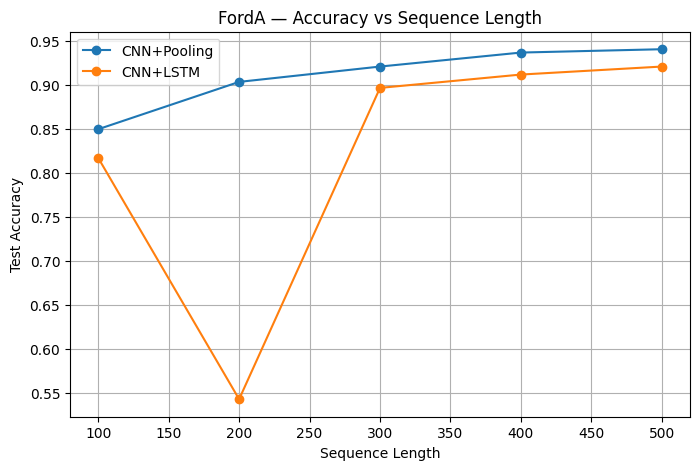

        pool_acc  lstm_acc
length                    
100     0.849242  0.816667
200     0.903030  0.542424
300     0.920455  0.896212
400     0.936364  0.911364
500     0.940152  0.920455


In [14]:
summary = length_df.groupby('length')[['pool_acc', 'lstm_acc']].mean()

plt.figure(figsize=(8, 5))
plt.plot(summary.index, summary['pool_acc'], marker='o', label='CNN+Pooling')
plt.plot(summary.index, summary['lstm_acc'], marker='o', label='CNN+LSTM')
plt.xlabel('Sequence Length')
plt.ylabel('Test Accuracy')
plt.title('FordA — Accuracy vs Sequence Length')
plt.legend()
plt.grid(True)
plt.show()

print(summary)